<a href="https://colab.research.google.com/github/PRANAY1836/Spam-Email-Classifier-using-Machine-Learning/blob/main/spamproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [10]:
from google.colab import files
uploaded = files.upload()

Saving spam (1).csv to spam (1) (1).csv


In [11]:
df = pd.read_csv("spam (1).csv")

print(df.head())


     v1                         v2
0   ham          Hello how are you
1  spam           Win money now!!!
2   ham        Let's meet tomorrow
3  spam  Claim your free prize now
4   ham   Are you coming to class?


In [12]:
df.columns = ['label', 'message']

In [13]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label_num'], test_size=0.2, random_state=42
)

In [15]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [16]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [17]:
y_pred = model.predict(X_test_tfidf)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 50.00%


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


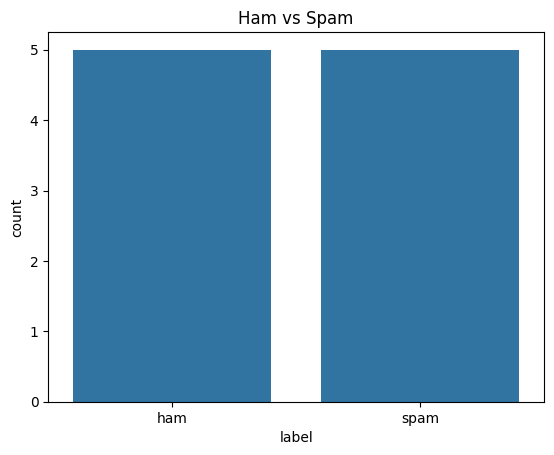

In [20]:
sns.countplot(x='label', data=df)
plt.title("Ham vs Spam")
plt.show()

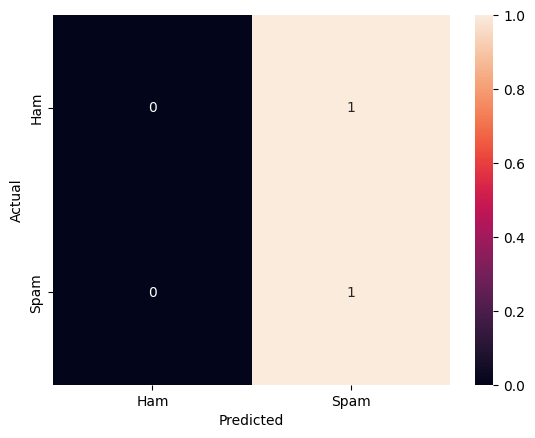

In [21]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
# ================================
# STEP 14: Test with User Input
# ================================

user_input = input("Enter a message: ")

# Convert input using same vectorizer
input_tfidf = vectorizer.transform([user_input])

# Predict
prediction = model.predict(input_tfidf)

# Output result
if prediction[0] == 1:
    print("🚨 This is SPAM message")
else:
    print("✅ This is HAM (Not Spam)")

Enter a message: Win money now!!!
🚨 This is SPAM message


In [23]:
import pickle

# Save model
pickle.dump(model, open("spam_model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))